## Подготовка окружения

### Импорты, seed и среда

In [1]:
import os
import json
import math
import random
from dataclasses import dataclass

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

import sklearn
from sklearn.linear_model import Ridge
from sklearn.preprocessing import StandardScaler
from sklearn.metrics import mean_absolute_error, root_mean_squared_error

import torch
from torch import nn
from torch.utils.data import Dataset, DataLoader

In [2]:
print("pandas: ", pd.__version__)
print("numpy:  ", np.__version__)
print("sklearn:", sklearn.__version__)
print("torch:  ", torch.__version__)

pandas:  2.2.2
numpy:   2.0.2
sklearn: 1.6.1
torch:   2.10.0+cpu


In [3]:
plt.rcParams["figure.figsize"] = (14, 5)
plt.rcParams["axes.grid"] = True
pd.set_option("display.max_columns", 100)
pd.set_option("display.width", 140)

In [4]:
def seed_everything(seed: int = 42) -> None:
    random.seed(seed)
    np.random.seed(seed)
    torch.manual_seed(seed)
    if torch.cuda.is_available():
        torch.cuda.manual_seed_all(seed)

SEED = 42
seed_everything(SEED)

In [5]:
DEVICE = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", DEVICE)

Device: cpu


In [6]:
os.makedirs("artifacts/figures", exist_ok=True)

### Данные и первичный анализ

In [7]:
df = pd.read_csv("S12-hw-dataset.csv")
df

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [8]:
df["date"] = pd.to_datetime(df["date"])
df = df.sort_values("date").reset_index(drop=True)
df

,date,target
0,2025-01-01 00:00:00,98.14
1,2025-01-01 01:00:00,98.07
2,2025-01-01 02:00:00,104.70
3,2025-01-01 03:00:00,112.81
4,2025-01-01 04:00:00,112.62
...,...,...
4315,2025-06-29 19:00:00,153.05
4316,2025-06-29 20:00:00,134.23
4317,2025-06-29 21:00:00,137.68
4318,2025-06-29 22:00:00,126.53


In [9]:
print(f"Количество наблюдений: {len(df)}")
print(f"Диапазон дат: {df["date"].min()} - {df["date"].max()}")
print("\nЧисло пропусков:")
print(df.isnull().sum())

Количество наблюдений: 4320
Диапазон дат: 2025-01-01 00:00:00 - 2025-06-29 23:00:00

Число пропусков:
date      0
target    0
dtype: int64


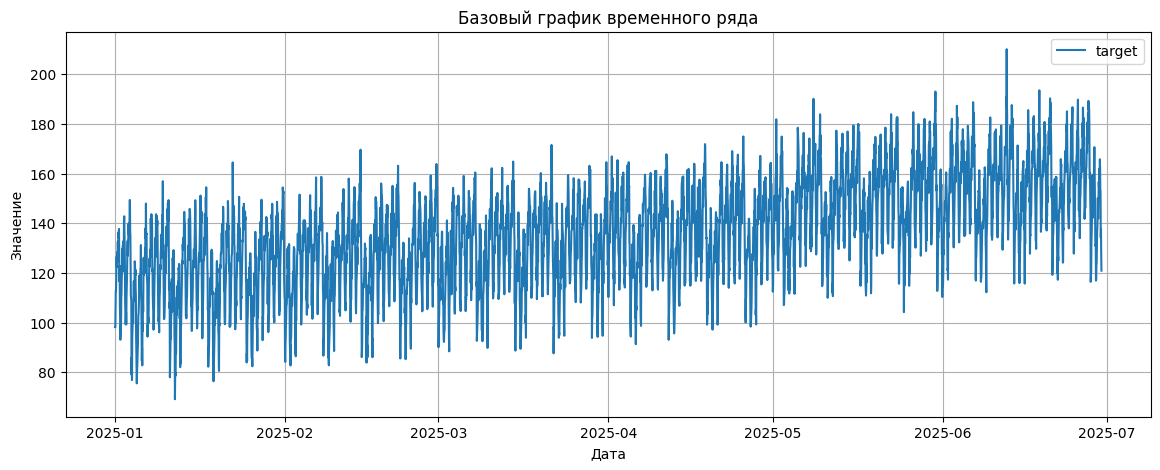

In [10]:
plt.figure()
plt.plot(df["date"], df["target"], label="target")
plt.title("Базовый график временного ряда")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.show()

### Корректный temporal split

In [11]:
@dataclass
class SplitConfig:
    train_frac: float = 0.70
    val_frac: float = 0.15

In [12]:
cfg = SplitConfig()
n = len(df)
train_size = int(n * cfg.train_frac)
val_size = int(n * cfg.val_frac)

train_df = df.iloc[:train_size].reset_index(drop=True)
val_df = df.iloc[train_size : train_size + val_size].reset_index(drop=True)
test_df = df.iloc[train_size + val_size :].reset_index(drop=True)

print(f"Train shape: {train_df.shape}")
print(f"Val shape:   {val_df.shape}")
print(f"Test shape:  {test_df.shape}")

print(f"\nTrain range: {train_df["date"].min()} - {train_df["date"].max()}")
print(f"Val range:   {val_df["date"].min()} - {val_df["date"].max()}")
print(f"Test range:  {test_df["date"].min()} - {test_df["date"].max()}")

Train shape: (3024, 2)
Val shape:   (648, 2)
Test shape:  (648, 2)

Train range: 2025-01-01 00:00:00 - 2025-05-06 23:00:00
Val range:   2025-05-07 00:00:00 - 2025-06-02 23:00:00
Test range:  2025-06-03 00:00:00 - 2025-06-29 23:00:00


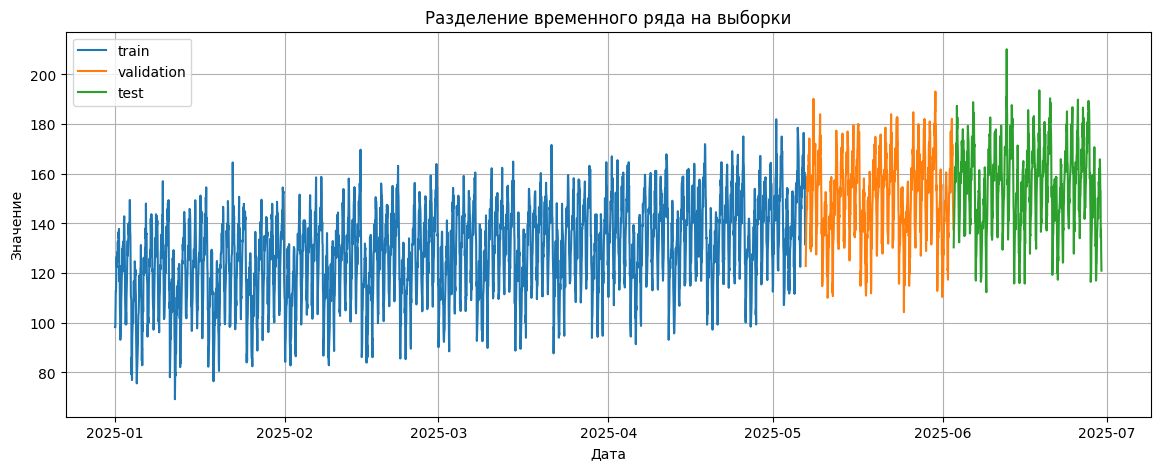

In [13]:
plt.figure()
plt.plot(train_df["date"], train_df["target"], label="train")
plt.plot(val_df["date"], val_df["target"], label="validation")
plt.plot(test_df["date"], test_df["target"], label="test")
plt.title("Разделение временного ряда на выборки")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.savefig("artifacts/figures/series_split.png", dpi=150, bbox_inches="tight")
plt.show()

`Random split` здесь некорректен, потому что модель должна учиться на прошлых и оцениваться на будущих данных, и случайное перемешивание здесь недопустимо.

### Признаки для baseline-моделей

In [14]:
def create_features(df_in):
    df_feat = df_in.copy()

    df_feat["lag_1"] = df_feat["target"].shift(1)
    df_feat["lag_7"] = df_feat["target"].shift(7)
    df_feat["lag_14"] = df_feat["target"].shift(14)

    df_feat["rolling_mean_7"] = df_feat["target"].shift(1).rolling(window=7).mean()
    df_feat["rolling_std_7"] = df_feat["target"].shift(1).rolling(window=7).std()

    df_feat["dayofweek"] = df_feat["date"].dt.dayofweek
    df_feat["hour"] = df_feat["date"].dt.hour

    return df_feat

df_with_features = create_features(df).dropna().reset_index(drop=True)

n_feat = len(df_with_features)
train_idx = int(n_feat * cfg.train_frac)
val_idx = int(n_feat * cfg.val_frac)

train_feat_df = df_with_features.iloc[:train_idx].reset_index(drop=True)
val_feat_df = df_with_features.iloc[train_idx : train_idx + val_idx].reset_index(drop=True)
test_feat_df = df_with_features.iloc[train_idx + val_idx :].reset_index(drop=True)

print(f"New Train shape: {train_feat_df.shape}")
display(train_feat_df.head())

New Train shape: (3014, 9)


,date,target,lag_1,lag_7,lag_14,rolling_mean_7,rolling_std_7,dayofweek,hour
0,2025-01-01 14:00:00,128.87,125.04,126.01,98.14,126.445714,3.275621,2,14
1,2025-01-01 15:00:00,136.40,128.87,122.38,98.07,126.854286,3.388632,2,15
2,2025-01-01 16:00:00,133.85,136.40,128.28,104.70,128.857143,4.318919,2,16
3,2025-01-01 17:00:00,137.71,133.85,124.43,112.81,129.652857,4.691868,2,17
4,2025-01-01 18:00:00,126.32,137.71,126.35,112.62,131.550000,4.907936,2,18


### Оконное представление для GRU

In [15]:
WINDOW_SIZE = 28
BATCH_SIZE = 64

In [16]:
scaler = StandardScaler()
scaler.fit(train_df[["target"]])

train_scaled = scaler.transform(train_df[["target"]])
val_scaled = scaler.transform(val_df[["target"]])
test_scaled = scaler.transform(test_df[["target"]])

In [17]:
class TSDataset(Dataset):
    def __init__(self, data, window_size):
        self.data = torch.FloatTensor(data)
        self.window_size = window_size

    def __len__(self):
        return len(self.data) - self.window_size

    def __getitem__(self, idx):
        x = self.data[idx : idx + self.window_size]
        y = self.data[idx + self.window_size, 0]
        return x, y

In [18]:
train_ds = TSDataset(train_scaled, WINDOW_SIZE)
val_ds = TSDataset(val_scaled, WINDOW_SIZE)
test_ds = TSDataset(test_scaled, WINDOW_SIZE)

train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
val_loader = DataLoader(val_ds, batch_size=BATCH_SIZE, shuffle=False)
test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)

In [19]:
print(f"Train samples: {len(train_ds)}")
x_batch, y_batch = next(iter(train_loader))
print(f"Batch X shape: {x_batch.shape}")
print(f"Batch Y shape: {y_batch.shape}")

Train samples: 2996
Batch X shape: torch.Size([64, 28, 1])
Batch Y shape: torch.Size([64])


### Базовые функции обучения и оценки

In [20]:
def calculate_metrics(y_true, y_pred):
    mae = mean_absolute_error(y_true, y_pred)
    rmse = root_mean_squared_error(y_true, y_pred)
    mape = np.mean(np.abs((y_true - y_pred) / y_true)) * 100

    return mae, rmse, mape

In [21]:
def train_epoch(model, loader, criterion, optimizer, device):
    model.train()
    train_loss = 0
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        optimizer.zero_grad()
        output = model(x)
        loss = criterion(output.squeeze(), y)
        loss.backward()
        optimizer.step()
        train_loss += loss.item() * x.size(0)
    return train_loss / len(loader.dataset)


@torch.no_grad()
def evaluate_loss(model, loader, criterion, device):
    model.eval()
    val_loss = 0
    y_true = []
    y_pred = []
    for x, y in loader:
        x, y = x.to(device), y.to(device)
        output = model(x)
        loss = criterion(output.squeeze(), y)
        val_loss += loss.item() * x.size(0)
        y_true.extend(y.cpu().numpy())
        y_pred.extend(output.squeeze().cpu().numpy())

    y_true = np.array(y_true)
    y_pred = np.array(y_pred)

    avg_loss = val_loss / len(loader.dataset)

    return avg_loss


def train_model(model, train_loader, val_loader, epochs, lr, device, path="best_model.pth"):
    model.to(device)
    optimizer = torch.optim.Adam(model.parameters(), lr=lr)
    criterion = nn.MSELoss()

    history = {"train_loss": [], "val_loss": []}
    best_val_loss = float("inf")
    best_state = None

    for epoch in range(1, epochs + 1):
        train_loss = train_epoch(model, train_loader, criterion, optimizer, device)
        val_loss = evaluate_loss(model, val_loader, criterion, device)

        history["train_loss"].append(train_loss)
        history["val_loss"].append(val_loss)

        if val_loss < best_val_loss:
            best_val_loss = val_loss
            best_state = model.state_dict()

        print(f"Epoch {epoch:02d} | train_loss={train_loss:.4f} | val_loss={val_loss:.4f}")

    if best_state is not None:
        model.load_state_dict(best_state)

    return history

## Эксперименты

### B1 (naive-last)

Наивный baseline, где прогноз равен последнему известному значению.

In [22]:
def naive_last(data):
    return data["lag_1"].values

In [23]:
y_true_b1 = val_feat_df["target"].values
y_pred_b1 = naive_last(val_feat_df)

mae_b1, rmse_b1, mape_b1 = calculate_metrics(y_true_b1, y_pred_b1)

print(f"MAE:  {mae_b1:.3f}")
print(f"RMSE: {rmse_b1:.3f}")
print(f"MAPE: {mape_b1:.2f}%")

MAE:  6.441
RMSE: 8.203
MAPE: 4.39%


### B2 (moving-average)

Baseline на основе скользящего среднего по окну разумного размера.

In [24]:
def moving_average(data):
    return data["rolling_mean_7"].values

In [25]:
y_true_b2 = val_feat_df["target"].values
y_pred_b2 = moving_average(val_feat_df)

mae_b2, rmse_b2, mape_b2 = calculate_metrics(y_true_b2, y_pred_b2)

print(f"MAE:  {mae_b2:.3f}")
print(f"RMSE: {rmse_b2:.3f}")
print(f"MAPE: {mape_b2:.2f}%")

MAE:  12.727
RMSE: 15.242
MAPE: 8.83%


### B3 (ridge-lag-features)

Ridge на лаговых, rolling- и календарных признаках.

In [26]:
features = ["lag_1", "lag_7", "lag_14", "rolling_mean_7", "rolling_std_7", "dayofweek", "hour"]
target = "target"

X_train, y_train = train_feat_df[features], train_feat_df[target]
X_val, y_val = val_feat_df[features], val_feat_df[target]

feat_scaler = StandardScaler()
X_train_scaled = feat_scaler.fit_transform(X_train)
X_val_scaled = feat_scaler.transform(X_val)

ridge_model = Ridge(random_state=SEED)
ridge_model.fit(X_train_scaled, y_train)

y_true_b3 = y_val.values
y_pred_b3 = ridge_model.predict(X_val_scaled)

mae_b3, rmse_b3, mape_b3 = calculate_metrics(y_true_b3, y_pred_b3)

print(f"MAE:  {mae_b3:.3f}")
print(f"RMSE: {rmse_b3:.3f}")
print(f"MAPE: {mape_b3:.2f}%")

MAE:  6.362
RMSE: 7.890
MAPE: 4.28%


### R1 (gru-forecast)

GRU на оконном представлении ряда.

In [27]:
class GRUModel(nn.Module):
    def __init__(self, input_dim, hidden_dim, num_layers=1, output_dim=1):
        super(GRUModel, self).__init__()
        self.hidden_dim = hidden_dim
        self.num_layers = num_layers
        self.gru = nn.GRU(input_dim, hidden_dim, num_layers, batch_first=True)
        self.fc = nn.Linear(hidden_dim, output_dim)

    def forward(self, x):
        h0 = torch.zeros(self.num_layers, x.size(0), self.hidden_dim).to(x.device)
        out, _ = self.gru(x, h0)
        out = self.fc(out[:, -1, :])
        return out

In [28]:
INPUT_DIM = 1
HIDDEN_DIM = 64
NUM_LAYERS = 2
EPOCHS = 30
LR = 1e-3

In [29]:
model_r1 = GRUModel(INPUT_DIM, HIDDEN_DIM, NUM_LAYERS)

history_r1 = train_model(
    model_r1,
    train_loader,
    val_loader,
    epochs=EPOCHS,
    lr=LR,
    device=DEVICE
)

Epoch 01 | train_loss=0.4788 | val_loss=0.2309
Epoch 02 | train_loss=0.1594 | val_loss=0.2330
Epoch 03 | train_loss=0.1527 | val_loss=0.1794
Epoch 04 | train_loss=0.1488 | val_loss=0.1812
Epoch 05 | train_loss=0.1458 | val_loss=0.2347
Epoch 06 | train_loss=0.1446 | val_loss=0.2944
Epoch 07 | train_loss=0.1389 | val_loss=0.1662
Epoch 08 | train_loss=0.1240 | val_loss=0.2021
Epoch 09 | train_loss=0.1122 | val_loss=0.2342
Epoch 10 | train_loss=0.1080 | val_loss=0.1938
Epoch 11 | train_loss=0.1062 | val_loss=0.1900
Epoch 12 | train_loss=0.1029 | val_loss=0.1608
Epoch 13 | train_loss=0.1034 | val_loss=0.2015
Epoch 14 | train_loss=0.1019 | val_loss=0.1883
Epoch 15 | train_loss=0.1030 | val_loss=0.1861
Epoch 16 | train_loss=0.1017 | val_loss=0.2255
Epoch 17 | train_loss=0.1015 | val_loss=0.2358
Epoch 18 | train_loss=0.1008 | val_loss=0.1804
Epoch 19 | train_loss=0.1043 | val_loss=0.1845
Epoch 20 | train_loss=0.0988 | val_loss=0.1693
Epoch 21 | train_loss=0.0985 | val_loss=0.1608
Epoch 22 | tr

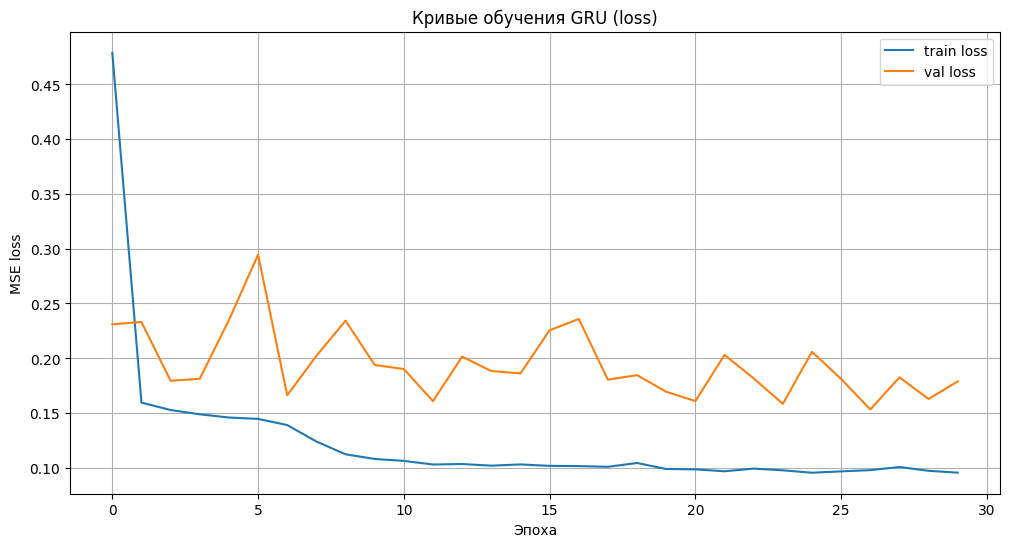

In [30]:
plt.figure(figsize=(12, 6))
plt.plot(history_r1["train_loss"], label="train loss")
plt.plot(history_r1["val_loss"], label="val loss")
plt.title("Кривые обучения GRU (loss)")
plt.xlabel("Эпоха")
plt.ylabel("MSE loss")
plt.legend()
plt.savefig("artifacts/figures/gru_learning_curves.png", dpi=150, bbox_inches="tight")
plt.show()

In [31]:
@torch.no_grad()
def evaluate_metrics(model, loader, device):
    model.eval()
    y_true = []
    y_pred = []

    for x, y in loader:
        x = x.to(device)
        output = model(x)
        y_true.extend(y.numpy())
        y_pred.extend(output.squeeze().cpu().numpy())

    y_true = np.array(y_true).reshape(-1, 1)
    y_pred = np.array(y_pred).reshape(-1, 1)

    y_true_inv = scaler.inverse_transform(y_true).flatten()
    y_pred_inv = scaler.inverse_transform(y_pred).flatten()

    mae, rmse, mape = calculate_metrics(y_true_inv, y_pred_inv)
    return mae, rmse, mape

In [32]:
mae_r1, rmse_r1, mape_r1 = evaluate_metrics(model_r1, val_loader, DEVICE)

print(f"MAE:  {mae_r1:.3f}")
print(f"RMSE: {rmse_r1:.3f}")
print(f"MAPE: {mape_r1:.2f}%")

MAE:  6.054
RMSE: 7.815
MAPE: 4.08%


In [33]:
torch.save(model_r1.state_dict(), "artifacts/best_gru.pt")

In [34]:
config = {
    "architecture": "GRU",
    "input_dim": INPUT_DIM,
    "hidden_dim": HIDDEN_DIM,
    "num_layers": NUM_LAYERS,
    "window_size": WINDOW_SIZE,
    "batch_size": BATCH_SIZE,
    "learning_rate": LR,
    "seed": SEED,
    "device": str(DEVICE),
    "feature_cols": INPUT_DIM,
    "scaler_mean": scaler.mean_.tolist(),
    "scaler_scale": scaler.scale_.tolist()
}

with open("artifacts/best_gru_config.json", "w") as f:
    json.dump(config, f, indent=4)

#### Лучший результат

In [35]:
val_results = {
    "Naive-last": mae_b1,
    "Moving-average": mae_b2,
    "Ridge": mae_b3,
    "GRU": mae_r1
}

best_model_name = min(val_results, key=val_results.get)
print(f"Лучшая модель по val: {best_model_name} (MAE: {val_results[best_model_name]:.3f})")

Лучшая модель по val: GRU (MAE: 6.054)


In [36]:
f_mae, f_rmse, f_mape = evaluate_metrics(model_r1, test_loader, DEVICE)

print(f"Результаты на test ({best_model_name}):")
print(f"MAE:  {f_mae:.3f}")
print(f"RMSE: {f_rmse:.3f}")
print(f"MAPE: {f_mape:.2f}%")

Результаты на test (GRU):
MAE:  7.275
RMSE: 9.226
MAPE: 4.70%


In [37]:
@torch.no_grad()
def get_predictions(model, loader, device):
    model.eval()
    preds = []
    trues = []
    for x, y in loader:
        x = x.to(device)
        output = model(x)
        preds.extend(output.squeeze().cpu().numpy())
        trues.extend(y.numpy())
    return np.array(trues), np.array(preds)

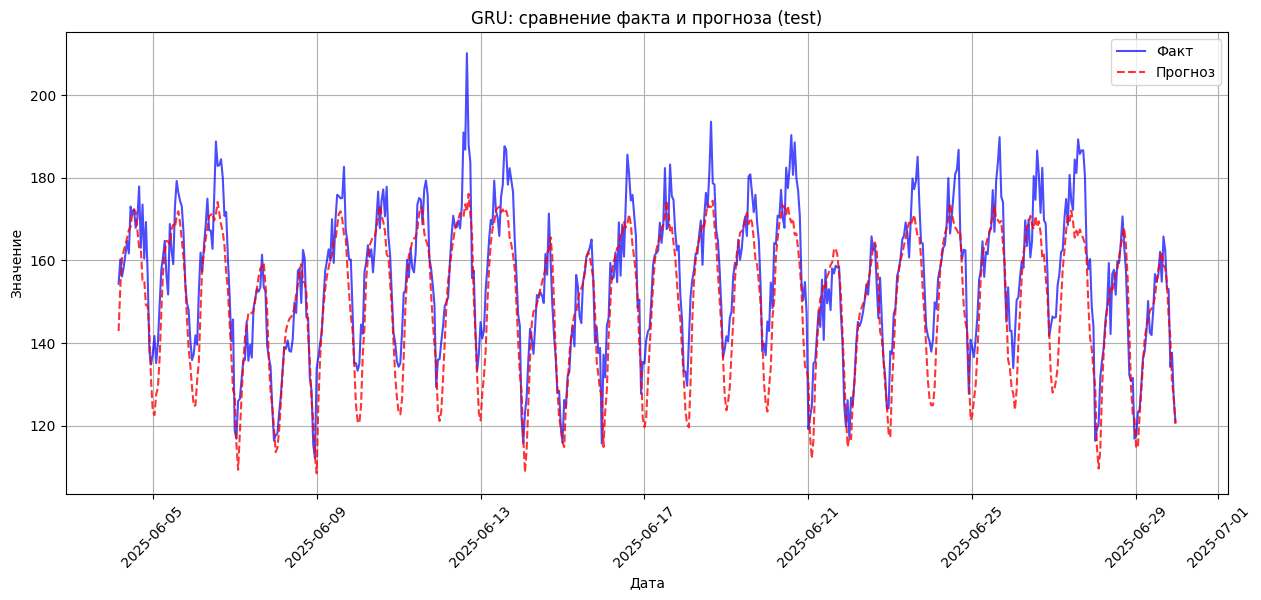

In [38]:
y_true_norm, y_pred_norm = get_predictions(model_r1, test_loader, DEVICE)

y_true_test = scaler.inverse_transform(y_true_norm.reshape(-1, 1)).flatten()
y_pred_test = scaler.inverse_transform(y_pred_norm.reshape(-1, 1)).flatten()

test_dates = test_df["date"].values[WINDOW_SIZE:]

plt.figure(figsize=(15, 6))
plt.plot(test_dates, y_true_test, label="Факт", color="blue", alpha=0.7)
plt.plot(test_dates, y_pred_test, label="Прогноз", color="red", linestyle="--", alpha=0.8)
plt.title("GRU: сравнение факта и прогноза (test)")
plt.xlabel("Дата")
plt.ylabel("Значение")
plt.legend()
plt.xticks(rotation=45)
plt.savefig("artifacts/figures/best_forecast_test.png", dpi=150, bbox_inches="tight")
plt.show()

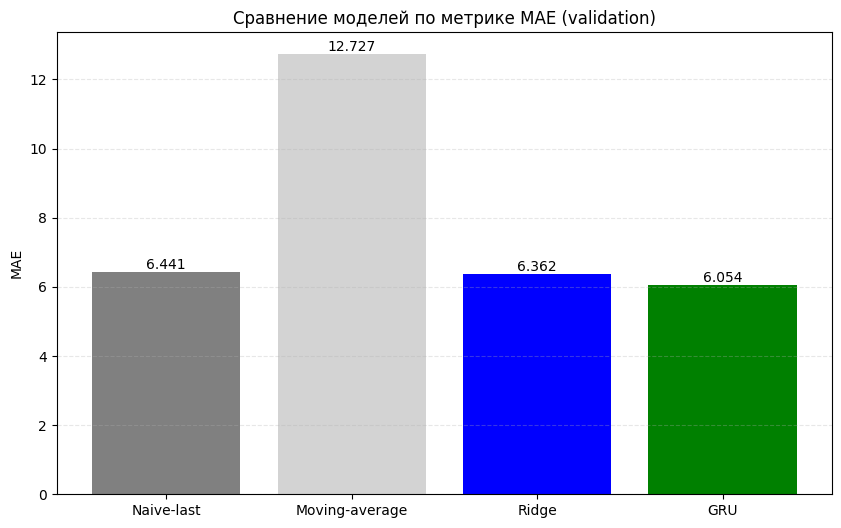

In [39]:
plt.figure(figsize=(10, 6))
model_names = list(val_results.keys())
mae_values = list(val_results.values())

bars = plt.bar(model_names, mae_values, color=["gray", "lightgray", "blue", "green"])
plt.title("Сравнение моделей по метрике MAE (validation)")
plt.ylabel("MAE")
plt.grid(False)
plt.grid(axis="y", alpha=0.3, linestyle="--")

for bar in bars:
    yval = bar.get_height()
    plt.text(bar.get_x() + bar.get_width()/2, yval, round(yval, 3), va="bottom", ha="center")

plt.savefig("artifacts/figures/baselines_compare.png", dpi=150, bbox_inches="tight")
plt.show()

In [40]:
runs_data = [
    {
        "experiment_id": "B1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": 1,
        "horizon": 1,
        "model_summary": "Naive-last",
        "features_summary": "lag_1",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": mae_b1,
        "best_val_rmse": rmse_b1,
        "best_val_mape": mape_b1,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Baseline: prediction = previous value"
    },
    {
        "experiment_id": "B2",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": 7,
        "horizon": 1,
        "model_summary": "Moving Average",
        "features_summary": "rolling_mean_7",
        "scaler": None,
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": mae_b2,
        "best_val_rmse": rmse_b2,
        "best_val_mape": mape_b2,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Baseline: weekly rolling mean"
    },
    {
        "experiment_id": "B3",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": 14,
        "horizon": 1,
        "model_summary": "Ridge Regression",
        "features_summary": "lags, rolling, calendar",
        "scaler": "StandardScaler",
        "optimizer": None,
        "lr": None,
        "epochs_trained": None,
        "best_val_mae": mae_b3,
        "best_val_rmse": rmse_b3,
        "best_val_mape": mape_b3,
        "test_mae": None,
        "test_rmse": None,
        "test_mape": None,
        "notes": "Classical linear model with feature engineering"
    },
    {
        "experiment_id": "R1",
        "task": "forecasting",
        "dataset": "S12-hw-dataset.csv",
        "seed": SEED,
        "split_summary": "70/15/15 temporal",
        "window_size": WINDOW_SIZE,
        "horizon": 1,
        "model_summary": f"GRU (hidden={HIDDEN_DIM}, layers={NUM_LAYERS})",
        "features_summary": "windowed sequences of all features",
        "scaler": "StandardScaler",
        "optimizer": "Adam",
        "lr": LR,
        "epochs_trained": EPOCHS,
        "best_val_mae": mae_r1,
        "best_val_rmse": rmse_r1,
        "best_val_mape": mape_r1,
        "test_mae": f_mae,
        "test_rmse": f_rmse,
        "test_mape": f_mape,
        "notes": "Recurrent Neural Network approach"
    }
]

runs_df = pd.DataFrame(runs_data)
runs_df.to_csv("artifacts/runs.csv", na_rep="", index=False)